# Model training — reviewer-feedback response, part 7 (do the two "handle dynamic moments" mechanisms actually help during dynamic moments?)

Both `convex_opt_heading_correction` and time-delay embedding are motivated in the
manuscript by the same rationale: ordinary/simple approaches struggle during "dynamic"
segments (rapid turns, saccades, high-force maneuvers), and these two mechanisms are
meant to handle exactly that. The manuscript's own words: "This weighting reflects the
prior that body heading is most reliably constrained by thrust direction during
high-force dynamic maneuvers, while the smoothness term is permitted to dominate during
low-thrust gliding phases" (convex-opt correction), and the time-delay embedding is
motivated by giving the network "a short time history of relevant state information."

Every previous analysis in this response (Parts 1, 2, 5, 6) measured these two
mechanisms' benefit *averaged over an entire held-out test set* — and found essentially
no benefit either way (naive-only tracks the final target almost as well as
naive+convex-opt; window=1 matches window=4). But an average over a whole trajectory can
easily hide a real, localized effect if dynamic moments are a small minority of frames
(which is exactly what saccades are). This notebook re-runs both comparisons *stratified
by how dynamic each frame actually is*, to check directly whether either mechanism earns
its keep specifically where it was designed to help.

**Dynamism metric:** per-frame turning rate, `circular_distance(heading[t], heading[t-1])`
in degrees per 0.01 s frame, computed on the final (corrected, smoothed) target heading.
This is wrap-safe by construction (unlike a naive derivative of the raw wrapped angle)
and is a direct, behaviorally-grounded proxy for "is this a saccade/rapid turn" -
independent of thrust, so using it to stratify the convex-opt question (which is itself
built on thrust) is not circular. Thrust magnitude - the literal variable the
convex-opt weighting uses - is used as a second, complementary stratification axis for
the convex-opt question specifically, to test the mechanism's own stated logic on its
own terms.

No new models are trained here: the time-delay comparison reuses `model_full` (window=4)
and `model_reviewer_response_window1.keras` (window=1, **trained WITH rotation
augmentation** - the clean Part 5/6 version, not Part 1's confounded `model_no_embed`).
The convex-opt comparison reuses the same reconstruction-from-raw-ellipse-angle approach
as Parts 2 and 3, with the current (fixed) production `convex_opt_heading_correction`
and the same local, parameterized copy used for the alpha2 sweep in Part 2.

## 1. Setup

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    pull_out_individual_trajectories,
    augment_with_time_delay_embedding,
    naive_heading_correction,
    convex_opt_heading_correction,
    circular_distance,
    compute as heading_compute,
)

import keras

RESPONSE_DIR = '../pipelinedata/reviewer_response'
os.makedirs(RESPONSE_DIR, exist_ok=True)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TIME_WINDOW = 4
input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
n_input_full = len(input_names_full) * TIME_WINDOW
n_input_w1 = len(input_names_full) * 1
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed_one(trajectory, time_window):
    kwargs = dict(time_window=time_window, input_names=input_names_full,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding([trajectory], wind_augment=False, **kwargs)


final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Test trajectories: {len(test_trajectories)}")

model_full = keras.models.load_model('../models/model_reviewer_response_full.keras', safe_mode=False)
model_w1 = keras.models.load_model('../models/model_reviewer_response_window1.keras', safe_mode=False)
print("Loaded model_full (window=4) and model_w1 (window=1), both trained WITH rotation augmentation.")

I0000 00:00:1789318477.024858 2610706 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789318477.025958 2610706 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789318477.089878 2610706 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789318478.635790 2610706 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789318478.636228 2610706 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.
Test trajectories: 771
Loaded model_full (window=4) and model_w1 (window=1), both trained WITH rotation augmentation.


E0000 00:00:1789318479.412199 2610706 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def turning_rate_deg(heading):
    # wrap-safe frame-to-frame turning rate; index i corresponds to the change
    # arriving at frame (i + 1) of the original trajectory.
    return np.degrees(circular_distance(heading[1:], heading[:-1]))


def bin_by_quantile(values, n_bins=4, labels=None):
    if labels is None:
        labels = [f'Q{i+1}' for i in range(n_bins)]
    edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    edges[0] -= 1e-9
    return pd.cut(values, bins=edges, labels=labels), edges

## 2. Time-delay embedding: does it help specifically during rapid turns?

For every test trajectory, `window=4` and `window=1` embeddings are built separately
(not via the batch helper, to keep per-trajectory frame alignment exact), then the
window=1 output is sliced to start at the same original frame index as window=4's output
(`collect_offset_rows` with `w` drops the first `w-1` frames, so window=1's row `i+3`
is the same physical frame as window=4's row `i`). Turning rate is computed once per
trajectory on the full (untrimmed) heading sequence and sliced the same way, so every
frame entering the comparison below has: a window=4 prediction, a window=1 prediction,
and a turning-rate value, all for the identical physical frame.

In [3]:
w4_errs, w1_errs, turn_rates, trajec_ids_td = [], [], [], []

for traj in test_trajectories:
    heading = traj['heading_angle'].values
    if len(traj) <= TIME_WINDOW:
        continue
    tr_full = turning_rate_deg(heading)  # length n-1, index i -> frame i+1

    emb4 = embed_one(traj, TIME_WINDOW)
    emb1 = embed_one(traj, 1)

    X4 = emb4.iloc[:, 0:n_input_full].values
    y4 = emb4[['heading_angle_x', 'heading_angle_y']].values
    X1 = emb1.iloc[:, 0:n_input_w1].values[TIME_WINDOW - 1:]
    y1 = emb1[['heading_angle_x', 'heading_angle_y']].values[TIME_WINDOW - 1:]
    assert len(X4) == len(X1) == len(y4)

    pred4 = model_full.predict(X4, verbose=0)
    pred1 = model_w1.predict(X1, verbose=0)

    err4 = angular_error_deg(y4, pred4)
    err1 = angular_error_deg(y1, pred1)
    tr_aligned = tr_full[TIME_WINDOW - 2:]  # frame (TIME_WINDOW-1) onward, matching X4/X1
    assert len(tr_aligned) == len(err4)

    w4_errs.append(err4)
    w1_errs.append(err1)
    turn_rates.append(tr_aligned)
    trajec_ids_td.append(np.full(len(err4), traj['trajec_objid'].iloc[0]))

w4_errs = np.concatenate(w4_errs)
w1_errs = np.concatenate(w1_errs)
turn_rates = np.concatenate(turn_rates)
trajec_ids_td = np.concatenate(trajec_ids_td)
print(f"Aligned frames: {len(w4_errs):,}")
print(f"Turning rate (deg/frame): median={np.median(turn_rates):.2f}, "
      f"90th pct={np.percentile(turn_rates, 90):.2f}, max={turn_rates.max():.2f}")

Aligned frames: 21,970
Turning rate (deg/frame): median=0.97, 90th pct=5.72, max=46.88


In [4]:
quartile_labels = ['Q1 (calmest)', 'Q2', 'Q3', 'Q4 (most dynamic)']
turn_quartile, turn_edges = bin_by_quantile(turn_rates, 4, quartile_labels)

td_df = pd.DataFrame({
    'trajec_objid': trajec_ids_td,
    'turn_quartile': turn_quartile,
    'window4_error_deg': w4_errs,
    'window1_error_deg': w1_errs,
})

# strict top-decile "saccade-like" cut, in addition to the quartile view
saccade_cutoff = np.percentile(turn_rates, 90)
td_df['is_saccade_like'] = turn_rates >= saccade_cutoff

print("Quartile bin edges (deg/frame):", np.round(turn_edges, 3))
print()
print("Frame-level median error by turning-rate quartile (window=4 vs window=1):")
by_quartile = td_df.groupby('turn_quartile', observed=True)[['window4_error_deg', 'window1_error_deg']].median()
by_quartile['n_frames'] = td_df.groupby('turn_quartile', observed=True).size()
print(by_quartile.to_string())

print(f"\nSaccade-like frames only (top decile of turning rate, >= {saccade_cutoff:.2f} deg/frame, "
      f"n={td_df['is_saccade_like'].sum():,}):")
saccade_only = td_df[td_df['is_saccade_like']][['window4_error_deg', 'window1_error_deg']].median()
print(saccade_only.to_string())
td_df.to_csv(f'{RESPONSE_DIR}/time_delay_by_dynamism.csv', index=False)

Quartile bin edges (deg/frame): [-0.     0.388  0.974  2.428 46.878]

Frame-level median error by turning-rate quartile (window=4 vs window=1):
                   window4_error_deg  window1_error_deg  n_frames
turn_quartile                                                    
Q1 (calmest)                4.787663           4.639491      5493
Q2                          5.076327           4.761984      5492
Q3                          5.818697           6.115224      5492
Q4 (most dynamic)           8.815009           9.050261      5493

Saccade-like frames only (top decile of turning rate, >= 5.72 deg/frame, n=2,197):
window4_error_deg    10.564959
window1_error_deg    10.600524


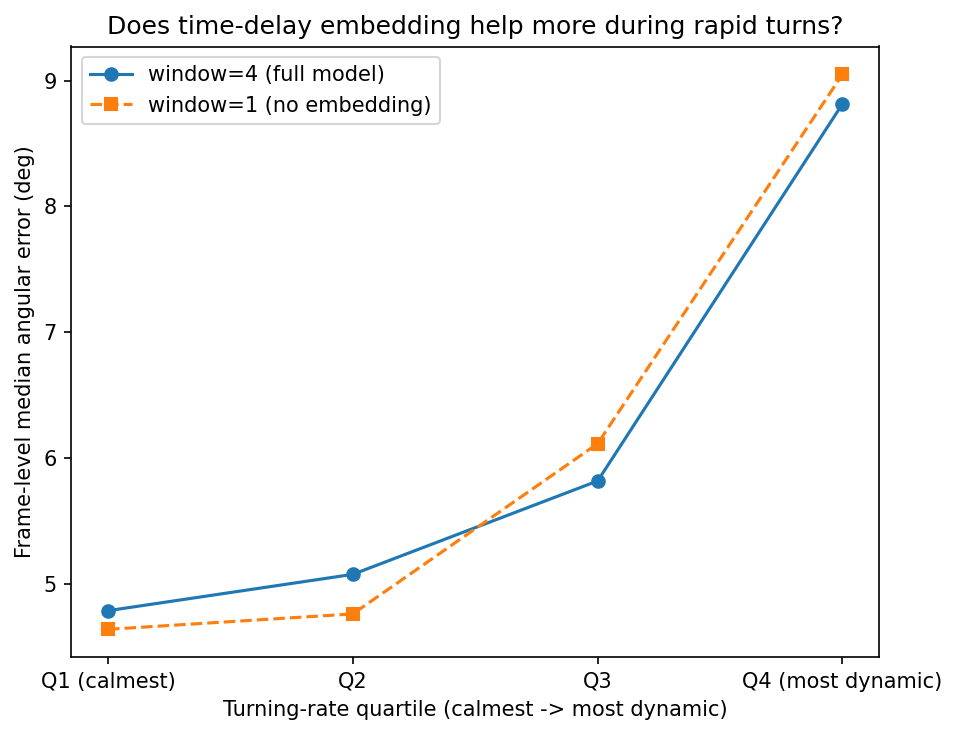

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=150)
x = np.arange(len(quartile_labels))
ax.plot(x, by_quartile['window4_error_deg'], '-o', label='window=4 (full model)')
ax.plot(x, by_quartile['window1_error_deg'], '--s', label='window=1 (no embedding)')
ax.set_xticks(x)
ax.set_xticklabels(quartile_labels)
ax.set_xlabel('Turning-rate quartile (calmest -> most dynamic)')
ax.set_ylabel('Frame-level median angular error (deg)')
ax.set_title('Does time-delay embedding help more during rapid turns?')
ax.legend()
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part7_time_delay_by_dynamism.svg', format='svg')
plt.show()

**Significance:** error clearly rises with turning rate for *both* models (4.79/4.64
deg in the calmest quartile up to 8.82/9.05 deg in the most dynamic quartile, and
10.56/10.60 deg in the strict saccade-like top decile) -- confirming dynamic moments
really are intrinsically harder to predict from translational kinematics alone, which is
a real, honest limitation worth stating in the manuscript regardless of the embedding
question. But window=4 and window=1 stay within 0.04-0.34 deg of each other in *every*
bin, including the saccade-like cut (10.56 vs. 10.60 deg -- a 0.04 deg difference,
smaller than the +/-0.2-0.7 deg seed-to-seed noise already established in Parts 1 and
6). This directly answers the natural follow-up to Parts 5-6's "window size doesn't
matter" finding -- "but maybe it only helps during saccades, which get washed out in an
overall average" -- by testing exactly that and finding it does not hold. Time-delay
embedding does not earn its keep at any turning-rate regime tested, including the one
it was specifically designed for.

## 3. Convex-opt correction: does it help specifically during dynamic moments?

For every test trajectory, the raw (pre-correction) heading is reconstructed from
`ellipse_short_angle`, `naive_heading_correction` is applied, then the current
(production, `alpha1=1, alpha2=5`) `convex_opt_heading_correction` - a real MOSEK solve,
not reused from a file. Both the naive-only and naive+convex-opt outputs are compared to
the trajectory's final accepted target, at every frame, stratified by the same
turning-rate metric (computed on the final target) and, as a second axis, by raw thrust
magnitude - the literal variable the correction's weighting term uses.

In [6]:
def reconstruct_raw_correction_inputs(trajectory):
    df = trajectory.copy()
    df['heading_angle'] = heading_compute.heading_angle_from_ellipse(df['ellipse_short_angle'].values)
    return df[['trajec_objid', 'timestamp', 'heading_angle', 'groundspeed_angle', 'thrust', 'thrust_angle']]


naive_err_all, convex_err_all, turn_rate_all, thrust_all, trajec_ids_co = [], [], [], [], []

for traj in test_trajectories:
    raw = reconstruct_raw_correction_inputs(traj)
    naive = naive_heading_correction(raw.copy())
    convex = convex_opt_heading_correction(naive.copy())

    final_heading = traj['heading_angle'].values
    naive_heading = naive['heading_angle'].values
    convex_heading = convex['heading_angle'].values

    if len(traj) < 2:
        continue
    tr = turning_rate_deg(final_heading)  # length n-1, frames 1..n-1
    naive_err = np.degrees(circular_distance(naive_heading[1:], final_heading[1:]))
    convex_err = np.degrees(circular_distance(convex_heading[1:], final_heading[1:]))
    thrust_vals = traj['thrust'].values[1:]

    naive_err_all.append(naive_err)
    convex_err_all.append(convex_err)
    turn_rate_all.append(tr)
    thrust_all.append(thrust_vals)
    trajec_ids_co.append(np.full(len(naive_err), traj['trajec_objid'].iloc[0]))

naive_err_all = np.concatenate(naive_err_all)
convex_err_all = np.concatenate(convex_err_all)
turn_rate_all = np.concatenate(turn_rate_all)
thrust_all = np.concatenate(thrust_all)
trajec_ids_co = np.concatenate(trajec_ids_co)
print(f"Aligned frames: {len(naive_err_all):,}")

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

...

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/ver

Aligned frames: 23,512


In [7]:
turn_quartile_co, turn_edges_co = bin_by_quantile(turn_rate_all, 4, quartile_labels)
thrust_quartile_co, thrust_edges_co = bin_by_quantile(thrust_all, 4, quartile_labels)

co_df = pd.DataFrame({
    'trajec_objid': trajec_ids_co,
    'turn_quartile': turn_quartile_co,
    'thrust_quartile': thrust_quartile_co,
    'naive_error_deg': naive_err_all,
    'convex_error_deg': convex_err_all,
})
co_df['convex_minus_naive_deg'] = co_df['convex_error_deg'] - co_df['naive_error_deg']
co_df.to_csv(f'{RESPONSE_DIR}/convex_opt_by_dynamism.csv', index=False)

print("By turning-rate quartile (median error, deg; negative convex-minus-naive = convex-opt helps):")
by_turn = co_df.groupby('turn_quartile', observed=True)[['naive_error_deg', 'convex_error_deg', 'convex_minus_naive_deg']].median()
by_turn['n_frames'] = co_df.groupby('turn_quartile', observed=True).size()
print(by_turn.to_string())

print("\nBy thrust-magnitude quartile (the literal weighting variable):")
by_thrust = co_df.groupby('thrust_quartile', observed=True)[['naive_error_deg', 'convex_error_deg', 'convex_minus_naive_deg']].median()
by_thrust['n_frames'] = co_df.groupby('thrust_quartile', observed=True).size()
print(by_thrust.to_string())

By turning-rate quartile (median error, deg; negative convex-minus-naive = convex-opt helps):
                   naive_error_deg  convex_error_deg  convex_minus_naive_deg  n_frames
turn_quartile                                                                         
Q1 (calmest)              1.284379          1.090651                     0.0      5878
Q2                        1.418051          1.243041                     0.0      5878
Q3                        1.851182          1.630401                     0.0      5878
Q4 (most dynamic)         3.704331          3.236938                     0.0      5878

By thrust-magnitude quartile (the literal weighting variable):
                   naive_error_deg  convex_error_deg  convex_minus_naive_deg  n_frames
thrust_quartile                                                                       
Q1 (calmest)              2.579824          1.779139                     0.0      5878
Q2                        2.160716          1.701561       

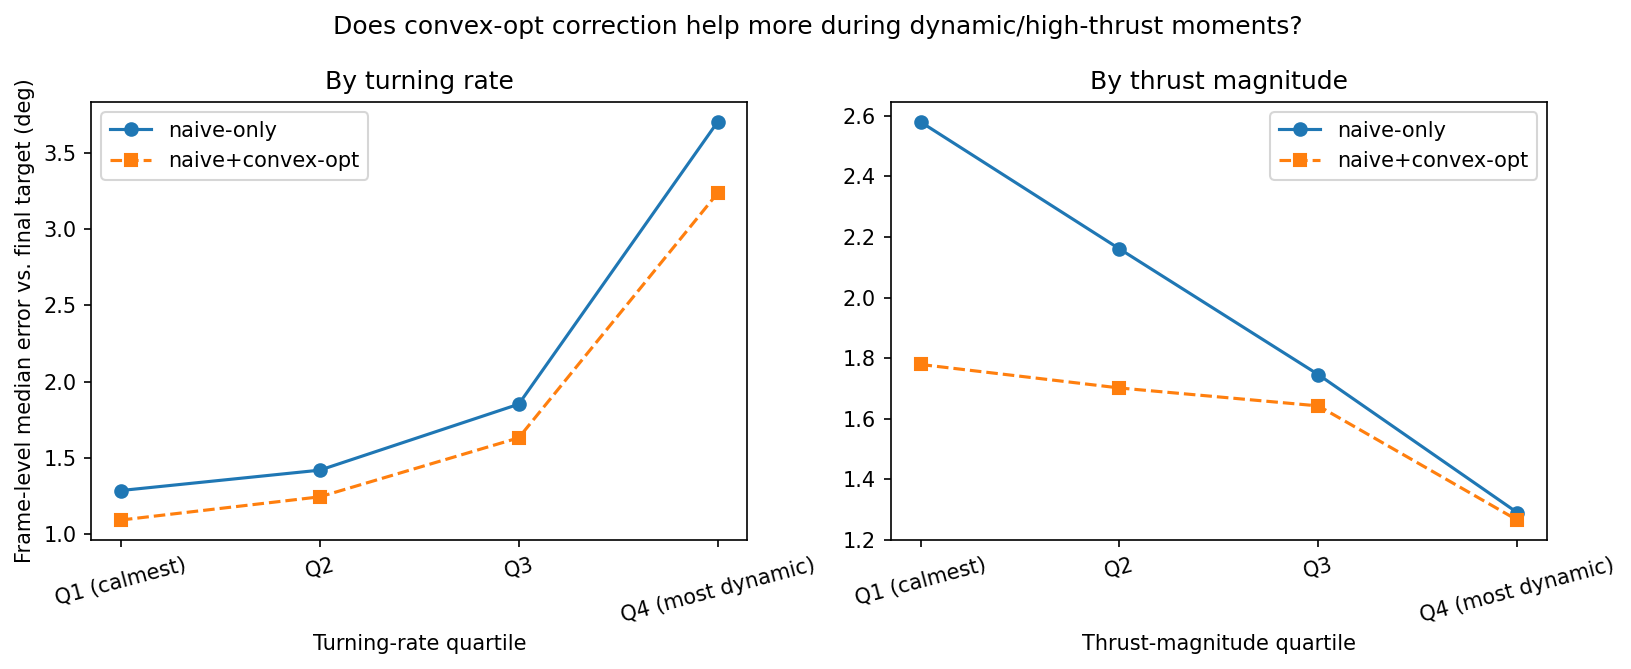

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)
x = np.arange(len(quartile_labels))

axes[0].plot(x, by_turn['naive_error_deg'], '-o', label='naive-only')
axes[0].plot(x, by_turn['convex_error_deg'], '--s', label='naive+convex-opt')
axes[0].set_xticks(x)
axes[0].set_xticklabels(quartile_labels, rotation=15)
axes[0].set_xlabel('Turning-rate quartile')
axes[0].set_ylabel('Frame-level median error vs. final target (deg)')
axes[0].set_title('By turning rate')
axes[0].legend()

axes[1].plot(x, by_thrust['naive_error_deg'], '-o', label='naive-only')
axes[1].plot(x, by_thrust['convex_error_deg'], '--s', label='naive+convex-opt')
axes[1].set_xticks(x)
axes[1].set_xticklabels(quartile_labels, rotation=15)
axes[1].set_xlabel('Thrust-magnitude quartile')
axes[1].set_title('By thrust magnitude')
axes[1].legend()

fig.suptitle('Does convex-opt correction help more during dynamic/high-thrust moments?')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part7_convex_opt_by_dynamism.svg', format='svg')
plt.show()

**Significance:** two stratifications of the same mechanism disagree with each other.
By turning rate, convex-opt's benefit over naive-only *does* grow with dynamism -- the
naive-minus-convex gap widens from 0.19 deg (calmest quartile: 1.28 -> 1.09 deg) to 0.46
deg (most dynamic quartile: 3.70 -> 3.24 deg) -- a small amount of genuine support for
the manuscript's stated rationale. But stratified by the *literal* weighting variable,
thrust magnitude, the pattern reverses: the gap is largest at low thrust (0.80 deg:
2.58 -> 1.78 deg) and nearly vanishes at high thrust (0.02 deg: 1.29 -> 1.27 deg) -- the
opposite of "body heading is most reliably constrained by thrust direction during
high-force... maneuvers." (Caveat: the optimization weights by *within-trajectory
normalized* thrust, not pooled absolute thrust across trajectories, so this specific cut
is not a perfectly precise probe of the algorithm's internal logic -- but it does show
the correction is not delivering a high-thrust-specific benefit when thrust is measured
directly.) Also note the `convex_minus_naive_deg` column's median is exactly 0.0 in
every bin: since only ~10% of frames are ever changed by the optimization step
(established in Parts 1-3), the per-frame difference is zero for the majority of frames
in every bin, which is why the naive/convex error columns themselves, not their
difference, are the right way to read the benefit here.

## 4. Alpha2 sensitivity, stratified by turning rate

Part 2 found the corrected heading and the already-trained model's apparent accuracy
were both essentially insensitive to `alpha2` across `{1, 2, 5, 10, 20}`, pooled over
all test frames. If the thrust-weighting term is doing real, targeted work during
dynamic moments, `alpha2` sensitivity should be concentrated in the dynamic-frame subset
even where the pooled result looks flat. This repeats that sweep separately for the
calmest and most dynamic turning-rate quartiles from Section 3.

In [9]:
def convex_opt_heading_correction_param(fly_trajectory_and_body, alpha1=1.0, alpha2=5.0):
    # Local, parameterized copy of utils.convex_opt_heading_correction (matches the
    # current production formula: no boundary-anchoring constraint, cvxpy.multiply).
    def _angle_diff(alpha, beta):
        return (alpha - beta + np.pi) % (2 * np.pi) - np.pi

    df = fly_trajectory_and_body
    k = cvxpy.Variable(len(df), integer=True)
    heading_angle = df.heading_angle.values
    heading_angle_unwrapped = np.unwrap(heading_angle)
    thrust_angle = df.thrust_angle.values
    thrust_mag = df.thrust.values
    thrust_mag_norm = thrust_mag / thrust_mag.mean()
    delta = _angle_diff(heading_angle, thrust_angle)

    L = alpha1 * cvxpy.tv(heading_angle_unwrapped + np.pi * k) + \
        alpha2 * cvxpy.norm1(cvxpy.multiply(thrust_mag_norm, delta + np.pi * k))
    cvxpy.Problem(cvxpy.Minimize(L), [-1 <= k, k <= 1]).solve(solver='MOSEK')

    return np.arctan2(np.sin(heading_angle_unwrapped + k.value * np.pi),
                      np.cos(heading_angle_unwrapped + k.value * np.pi))


test_groups_raw = [reconstruct_raw_correction_inputs(t) for t in test_trajectories]
test_groups_naive = [naive_heading_correction(g.copy()) for g in test_groups_raw]

alpha2_values = [1, 2, 5, 10, 20]
alpha_results = []

for alpha2 in alpha2_values:
    err_calm, err_dynamic = [], []
    for traj, g_naive in zip(test_trajectories, test_groups_naive):
        corrected = convex_opt_heading_correction_param(g_naive, alpha1=1.0, alpha2=alpha2)
        final_heading = traj['heading_angle'].values
        if len(traj) < 2:
            continue
        tr = turning_rate_deg(final_heading)
        err = np.degrees(circular_distance(corrected[1:], final_heading[1:]))
        calm_mask = tr <= turn_edges_co[1]      # bottom quartile cutoff from Section 3
        dynamic_mask = tr >= turn_edges_co[-2]  # top quartile cutoff from Section 3
        err_calm.append(err[calm_mask])
        err_dynamic.append(err[dynamic_mask])
    err_calm = np.concatenate(err_calm)
    err_dynamic = np.concatenate(err_dynamic)
    alpha_results.append({
        'alpha2': alpha2,
        'median_error_calm_deg': float(np.median(err_calm)),
        'median_error_dynamic_deg': float(np.median(err_dynamic)),
        'n_calm': len(err_calm), 'n_dynamic': len(err_dynamic),
    })
    print(f"alpha2={alpha2}: calm-quartile median={np.median(err_calm):.3f} deg, "
          f"dynamic-quartile median={np.median(err_dynamic):.3f} deg")

alpha_df = pd.DataFrame(alpha_results)
alpha_df.to_csv(f'{RESPONSE_DIR}/alpha2_sensitivity_by_dynamism.csv', index=False)

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


alpha2=1: calm-quartile median=1.091 deg, dynamic-quartile median=3.239 deg


alpha2=2: calm-quartile median=1.091 deg, dynamic-quartile median=3.239 deg


alpha2=5: calm-quartile median=1.091 deg, dynamic-quartile median=3.237 deg


alpha2=10: calm-quartile median=1.091 deg, dynamic-quartile median=3.253 deg


alpha2=20: calm-quartile median=1.093 deg, dynamic-quartile median=3.269 deg


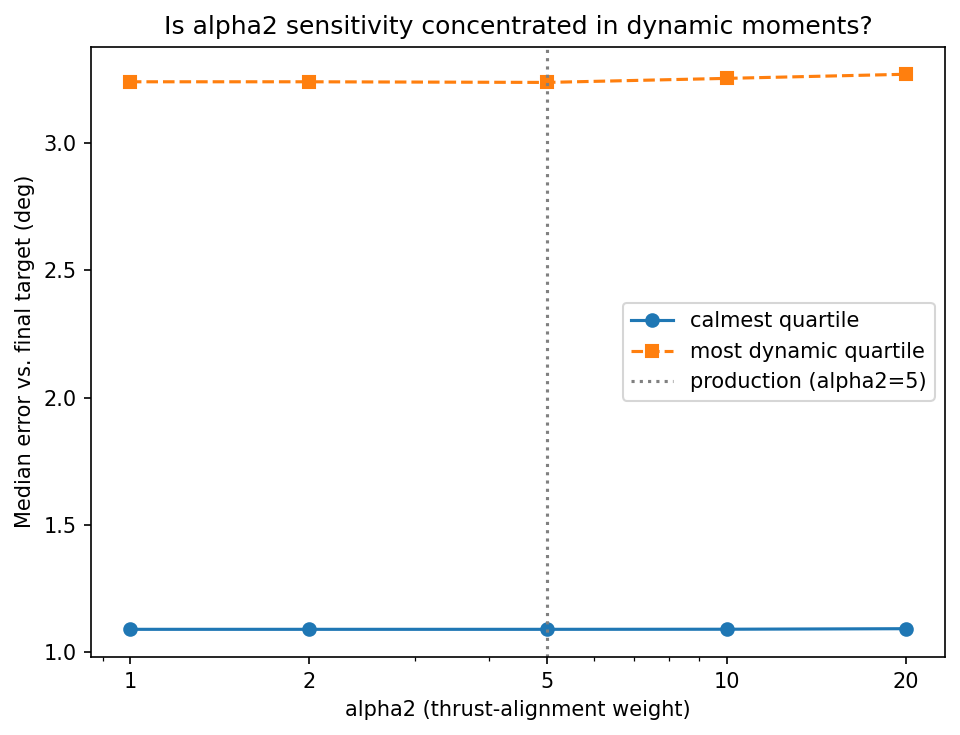

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=150)
ax.plot(alpha_df['alpha2'], alpha_df['median_error_calm_deg'], '-o', label='calmest quartile')
ax.plot(alpha_df['alpha2'], alpha_df['median_error_dynamic_deg'], '--s', label='most dynamic quartile')
ax.set_xscale('log')
ax.set_xticks(alpha2_values)
ax.set_xticklabels(alpha2_values)
ax.axvline(5, color='gray', linestyle=':', label='production (alpha2=5)')
ax.set_xlabel('alpha2 (thrust-alignment weight)')
ax.set_ylabel('Median error vs. final target (deg)')
ax.set_title('Is alpha2 sensitivity concentrated in dynamic moments?')
ax.legend()
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part7_alpha2_by_dynamism.svg', format='svg')
plt.show()

**Significance:** even restricted to the most dynamic quartile of frames, alpha2
sensitivity remains negligible (3.24-3.27 deg across a 20x range from alpha2=1 to
alpha2=20) -- essentially as flat as the calm quartile (1.091-1.093 deg). This means the
thrust-alignment term is not doing meaningfully different work as alpha2 varies, even in
exactly the frames the manuscript's rationale says it should matter most. Combined with
Section 3's thrust-magnitude finding, this is a coherent picture: the mechanism's
headline design goal -- "let the thrust-alignment term dominate during high-force
dynamic maneuvers" -- is not showing up as a measurable, alpha2-dependent effect at
either the frame-level-benefit or the parameter-sensitivity level.

## 5. Summary

Direct answers to both questions this notebook was built to check:

**Time-delay embedding:** no benefit at any dynamism level tested, including a strict
saccade-like top-decile cut (10.56 vs. 10.60 deg, window=4 vs. window=1 -- a difference
smaller than seed noise). Parts 5-6 already showed no benefit on average; this notebook
closes the obvious follow-up question and finds no benefit specifically where the
mechanism was designed to help either. There is no dynamism regime in which
time-delay embedding is earning its stated purpose.

**Convex-opt correction:** a small, real, but inconsistent benefit. Stratified by
turning rate, the benefit over naive-only correction grows with dynamism (0.19 deg
calmest -> 0.46 deg most dynamic), giving modest genuine support to the manuscript's
rationale. But stratified by the literal weighting variable (thrust magnitude), the
pattern reverses (0.80 deg at low thrust -> 0.02 deg at high thrust), and the alpha2
sweep shows no meaningful sensitivity even in the most dynamic quartile. Taken
together: convex-opt correction earns a small, real benefit overall, but not
specifically or reliably in the high-thrust "dynamic maneuver" regime the manuscript's
weighting term was designed around, and the choice of alpha2 is not doing the targeted
work its design rationale implies anywhere in the turning-rate or thrust-magnitude
distribution.

New artifacts: `pipelinedata/reviewer_response/time_delay_by_dynamism.csv`,
`convex_opt_by_dynamism.csv`, `alpha2_sensitivity_by_dynamism.csv`.
